In [36]:
import pandas as pd
from pathlib import Path

data_path = Path("../data/raw/ai4i2020.csv")
data_path.exists()

df = pd.read_csv(data_path)

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [37]:
df.shape

(10000, 14)

In [38]:
df.columns.tolist()

['UDI',
 'Product ID',
 'Type',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Machine failure',
 'TWF',
 'HDF',
 'PWF',
 'OSF',
 'RNF']

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [40]:
df.isna().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [41]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [42]:
df["Machine failure"].value_counts(normalize=True).mul(100).round(2)

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

In [43]:
target_column = "Machine failure"

id_columns = ["UDI", "Product ID"]
leakage_columns = ["TWF", "HDF", "PWF", "OSF", "RNF"]

feature_columns = [
    column
    for column in df.columns
    if column not in id_columns + leakage_columns + [target_column]
]

feature_columns

['Type',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]']

In [44]:
numeric_feature_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

df.groupby("Machine failure")[numeric_feature_columns].mean().round(2)

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Machine failure,,,,,
0,299.97,310.00,1540.26,39.63,106.69
1,300.89,310.29,1496.49,50.17,143.78


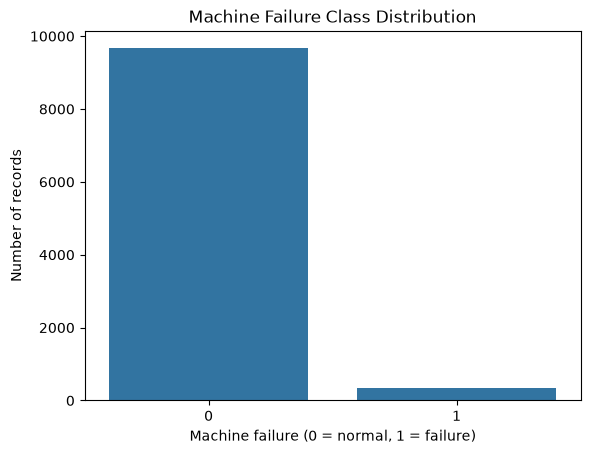

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="Machine failure")
plt.title("Machine Failure Class Distribution")
plt.xlabel("Machine failure (0 = normal, 1 = failure)")
plt.ylabel("Number of records")
plt.show()

In [46]:
from sklearn.model_selection import train_test_split

X = df[feature_columns]
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(8000, 6) (2000, 6)
Machine failure
0    7729
1     271
Name: count, dtype: int64
Machine failure
0    1932
1      68
Name: count, dtype: int64


In [47]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix

dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train, y_train)

dummy_predictions = dummy_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, dummy_predictions))
print("Recall:", recall_score(y_test, dummy_predictions))
print("Confusion matrix:")
print(confusion_matrix(y_test, dummy_predictions))

Accuracy: 0.966
Recall: 0.0
Confusion matrix:
[[1932    0]
 [  68    0]]


In [48]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

numeric_X_train = X_train[numeric_feature_columns]
numeric_X_test = X_test[numeric_feature_columns]

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000)),
])

logistic_model.fit(numeric_X_train, y_train)

logistic_predictions = logistic_model.predict(numeric_X_test)

print("Accuracy:", accuracy_score(y_test, logistic_predictions))
print("Recall:", recall_score(y_test, logistic_predictions))
print("Confusion matrix:")
print(confusion_matrix(y_test, logistic_predictions))

Accuracy: 0.821
Recall: 0.8382352941176471
Confusion matrix:
[[1585  347]
 [  11   57]]


In [49]:
#Random Forest Model

from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

random_forest_model.fit(numeric_X_train, y_train)

random_forest_predictions = random_forest_model.predict(numeric_X_test)

print("Accuracy:", accuracy_score(y_test, random_forest_predictions))
print("Recall:", recall_score(y_test, random_forest_predictions))
print("Confusion matrix:")
print(confusion_matrix(y_test, random_forest_predictions))

Accuracy: 0.981
Recall: 0.7058823529411765
Confusion matrix:
[[1914   18]
 [  20   48]]


In [62]:
#random forest model’s probabilities instead of normal 0 and 1 (yes and no)

random_forest_probabilities = random_forest_model.predict_proba(numeric_X_test)[:, 1]

threshold_rows = []

for threshold in [0.30, 0.50, 0.70]:
    threshold_predictions = (
        random_forest_probabilities >= threshold
    ).astype(int)

    threshold_rows.append({
        "Threshold": threshold,
        "Recall": recall_score(y_test, threshold_predictions),
        "Precision": precision_score(y_test, threshold_predictions),
        "False alarms": confusion_matrix(y_test, threshold_predictions)[0, 1],
        "Missed failures": confusion_matrix(y_test, threshold_predictions)[1, 0],
    })

pd.DataFrame(threshold_rows).round(3)

,Threshold,Recall,Precision,False alarms,Missed failures
0,0.3,0.824,0.491,58,12
1,0.5,0.706,0.727,18,20
2,0.7,0.529,0.837,7,32


In [55]:
#xgboost model

from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

failure_weight = (y_train == 0).sum() / (y_train == 1).sum()

safe_column_names = {
    "Air temperature [K]": "air_temperature_k",
    "Process temperature [K]": "process_temperature_k",
    "Rotational speed [rpm]": "rotational_speed_rpm",
    "Torque [Nm]": "torque_nm",
    "Tool wear [min]": "tool_wear_min",
}

xgb_X_train = numeric_X_train.rename(columns=safe_column_names)
xgb_X_test = numeric_X_test.rename(columns=safe_column_names)

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=failure_weight,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1,
)

xgb_model.fit(xgb_X_train, y_train)

xgb_probabilities = xgb_model.predict_proba(xgb_X_test)[:, 1]
xgb_predictions = (xgb_probabilities >= 0.50).astype(int)

print("Accuracy:", accuracy_score(y_test, xgb_predictions))
print("Precision:", precision_score(y_test, xgb_predictions))
print("Recall:", recall_score(y_test, xgb_predictions))
print("F1:", f1_score(y_test, xgb_predictions))
print("ROC-AUC:", roc_auc_score(y_test, xgb_probabilities))

Accuracy: 0.9635
Precision: 0.4789915966386555
Recall: 0.8382352941176471
F1: 0.6096256684491979
ROC-AUC: 0.971859395932286


In [61]:
#Model Comparison between 4

model_predictions = {
    "Dummy baseline": dummy_predictions,
    "Logistic Regression": logistic_predictions,
    "Random Forest": random_forest_predictions,
    "XGBoost": xgb_predictions,
}

results = pd.DataFrame([
    {
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions),
        "F1 score": f1_score(y_test, predictions, zero_division=0),
    }
    for name, predictions in model_predictions.items()
]).round(3)

results

,Model,Accuracy,Precision,Recall,F1 score
0,Dummy baseline,0.966,0.000,0.000,0.000
1,Logistic Regression,0.821,0.141,0.838,0.242
2,Random Forest,0.981,0.727,0.706,0.716
3,XGBoost,0.964,0.479,0.838,0.610


In [68]:
#xgb for modal probabilities
xgb_threshold_rows = []

for threshold in [0.30, 0.50, 0.70]:
    threshold_predictions = (xgb_probabilities >= threshold).astype(int)

    matrix = confusion_matrix(y_test, threshold_predictions)

    xgb_threshold_rows.append({
        "Threshold": threshold,
        "Recall": recall_score(y_test, threshold_predictions),
        "Precision": precision_score(y_test, threshold_predictions),
        "False alarms": matrix[0, 1],
        "Missed failures": matrix[1, 0],
    })

pd.DataFrame(xgb_threshold_rows).round(3)

,Threshold,Recall,Precision,False alarms,Missed failures
0,0.3,0.868,0.349,110,9
1,0.5,0.838,0.479,62,11
2,0.7,0.794,0.614,34,14


,Feature,Importance
2,rotational_speed_rpm,0.357819
3,torque_nm,0.270706
4,tool_wear_min,0.244939
0,air_temperature_k,0.074672
1,process_temperature_k,0.051864


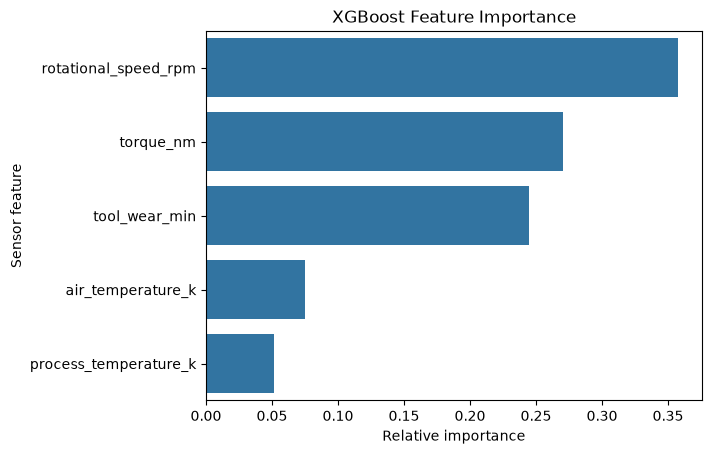

In [72]:
#feature importance xgb what is the importance of feature that cause the machine failure

feature_importance = pd.DataFrame({
    "Feature": xgb_X_train.columns,
    "Importance": xgb_model.feature_importances_,
}).sort_values("Importance", ascending=False)

display(feature_importance)

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
)
plt.title("XGBoost Feature Importance")
plt.xlabel("Relative importance")
plt.ylabel("Sensor feature")
plt.show()

In [75]:
#Type: converting type like l,m,h into number like encoding exp: l[1,0,0] M[0,1,0]

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

safe_feature_names = {
    "Air temperature [K]": "air_temperature_k",
    "Process temperature [K]": "process_temperature_k",
    "Rotational speed [rpm]": "rotational_speed_rpm",
    "Torque [Nm]": "torque_nm",
    "Tool wear [min]": "tool_wear_min",
    "Type": "type",
}

xgb_all_train = X_train.rename(columns=safe_feature_names)
xgb_all_test = X_test.rename(columns=safe_feature_names)

preprocessor = ColumnTransformer([
    (
        "numeric",
        "passthrough",
        [
            "air_temperature_k",
            "process_temperature_k",
            "rotational_speed_rpm",
            "torque_nm",
            "tool_wear_min",
        ],
    ),
    ("type", OneHotEncoder(handle_unknown="ignore"), ["type"]),
])

xgb_with_type = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            scale_pos_weight=failure_weight,
            random_state=42,
            eval_metric="logloss",
            n_jobs=-1,
        ),
    ),
])

xgb_with_type.fit(xgb_all_train, y_train)

xgb_type_probabilities = xgb_with_type.predict_proba(xgb_all_test)[:, 1]
xgb_type_predictions = (xgb_type_probabilities >= 0.50).astype(int)

print("Accuracy:", accuracy_score(y_test, xgb_type_predictions))
print("Precision:", precision_score(y_test, xgb_type_predictions))
print("Recall:", recall_score(y_test, xgb_type_predictions))
print("F1:", f1_score(y_test, xgb_type_predictions))
print("ROC-AUC:", roc_auc_score(y_test, xgb_type_probabilities))

Accuracy: 0.964
Precision: 0.4824561403508772
Recall: 0.8088235294117647
F1: 0.6043956043956044
ROC-AUC: 0.9680459140177811


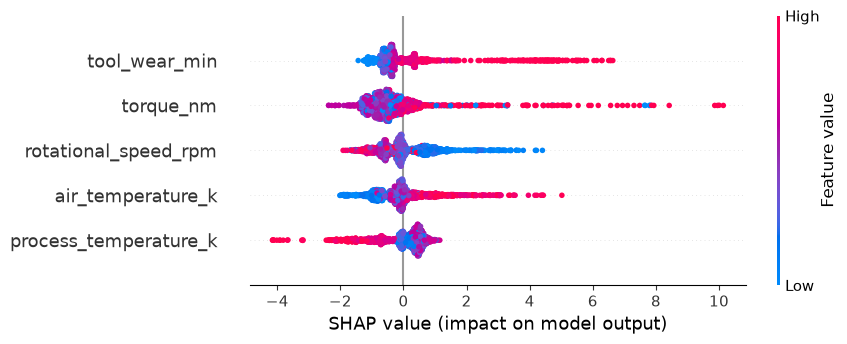

In [77]:
import shap

explainer = shap.Explainer(xgb_model, xgb_X_train)
shap_values = explainer(xgb_X_test)

shap.plots.beeswarm(shap_values, max_display=5)

Predicted failure probability: 99.8%
Actual outcome: Failure


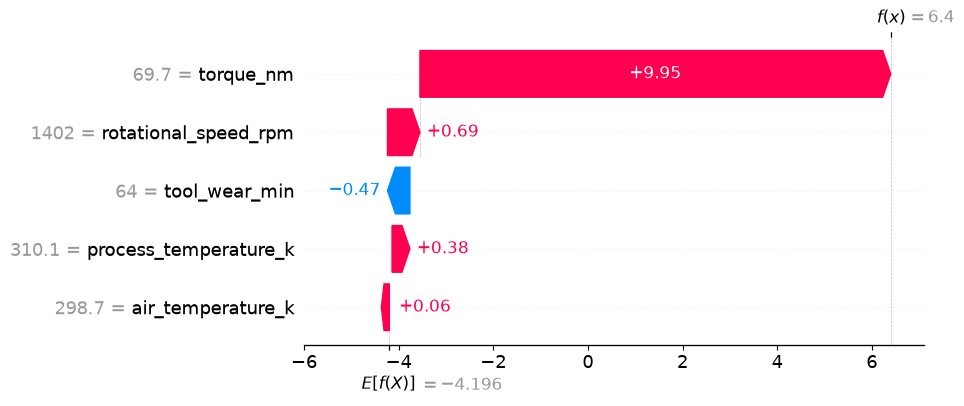

In [78]:
highest_risk_position = xgb_probabilities.argmax()

print(
    "Predicted failure probability:",
    f"{xgb_probabilities[highest_risk_position]:.1%}",
)
print(
    "Actual outcome:",
    "Failure" if y_test.iloc[highest_risk_position] == 1 else "Normal",
)

shap.plots.waterfall(shap_values[highest_risk_position])

In [ ]:
## Phase 1 conclusion

- The dataset contained 10,000 machine records, with failures representing 3.39% of cases.
- Accuracy alone was misleading because a model could predict only normal cases and still appear accurate.
- XGBoost using numeric sensor features was the strongest current candidate.
- At a 0.50 alert threshold, it achieved 83.8% recall, caught 57 of 68 failures, and generated 62 false alarms.
- SHAP showed which sensor readings influenced individual risk predictions.
- This model is decision support only; real maintenance decisions require qualified engineer review.